# Titanic Dataset - Exploratory Data Analysis

## Objective

The objective of this notebook is to understand the Titanic dataset and identify preprocessing decisions required before feature engineering and machine learning.

This notebook focuses on:

- Data understanding
- Missing value analysis
- Feature distributions
- Relationships with target variable
- Outlier detection
- Correlation analysis
- Preprocessing recommendations

No feature engineering or model training is performed in this notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Overview

The Titanic dataset contains passenger information and survival outcomes.

Target Variable:

- Survived

Prediction Goal:

Predict whether a passenger survived the Titanic disaster.

In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
(df.isnull().sum()/len(df))*100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


# Missing Value Conclusions

- Cabin contains excessive missing values and may be removed.
- Age contains moderate missing values and should be imputed using the median.
- Embarked contains very few missing values and can be imputed using the mode.

In [11]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [13]:
df['Sex'] = df['Sex'].astype('category')

In [14]:
df['Embarked'] = df['Embarked'].astype('category')

Converted the object data type to categorical because it contains categorical string only

In [15]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,category
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [16]:
unique ={}
for col in df.columns:
  unique[col] = df[col].nunique()

In [17]:
unique

{'PassengerId': 891,
 'Survived': 2,
 'Pclass': 3,
 'Name': 891,
 'Sex': 2,
 'Age': 88,
 'SibSp': 7,
 'Parch': 7,
 'Ticket': 681,
 'Fare': 248,
 'Cabin': 147,
 'Embarked': 3}

In [18]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [19]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


<Axes: xlabel='Survived', ylabel='count'>

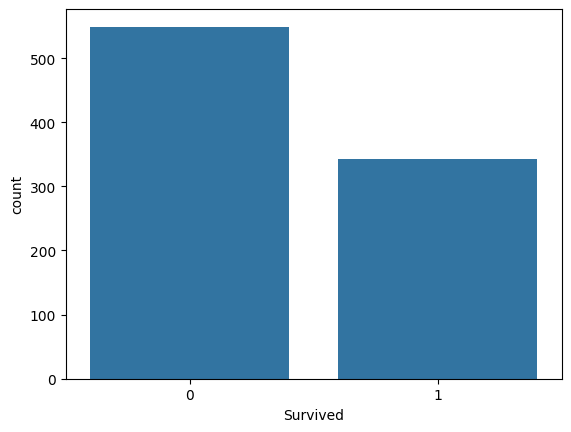

In [20]:
sns.countplot(data=df,x='Survived')

**Observation:**

Target feature is imbalance here class 0 has more data than class 1

# **Univariate Analysis**

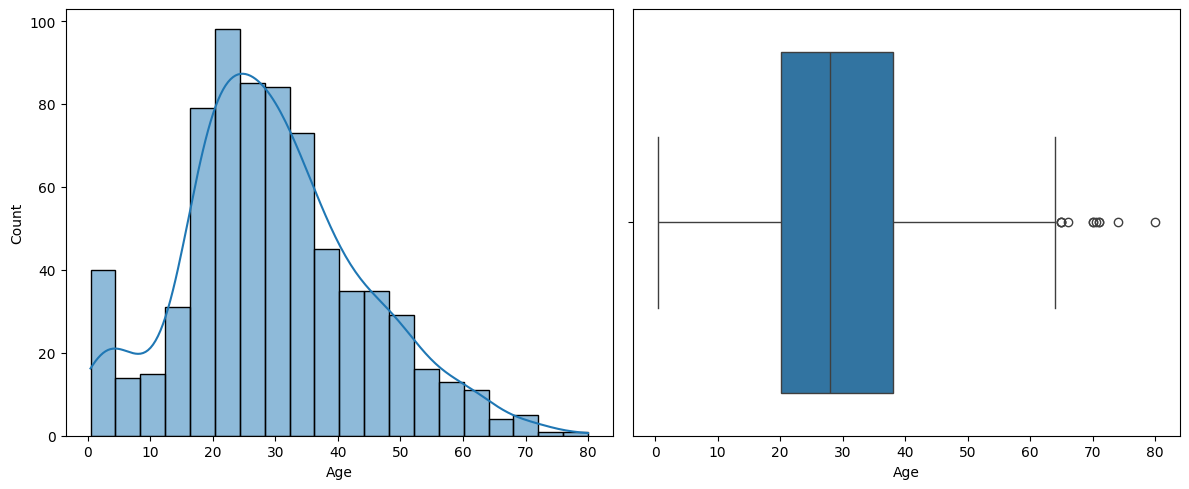

In [21]:
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df['Age'], kde=True)

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df['Age'])

plt.tight_layout()
plt.show()

**Observation:**

- Age feature is sligthly skwed to right and most of the data is concentrated age 10 to 40 and there are few outliers on the right side

**Decision:**

- we have to use log transformation to make the skewed data normally distributed

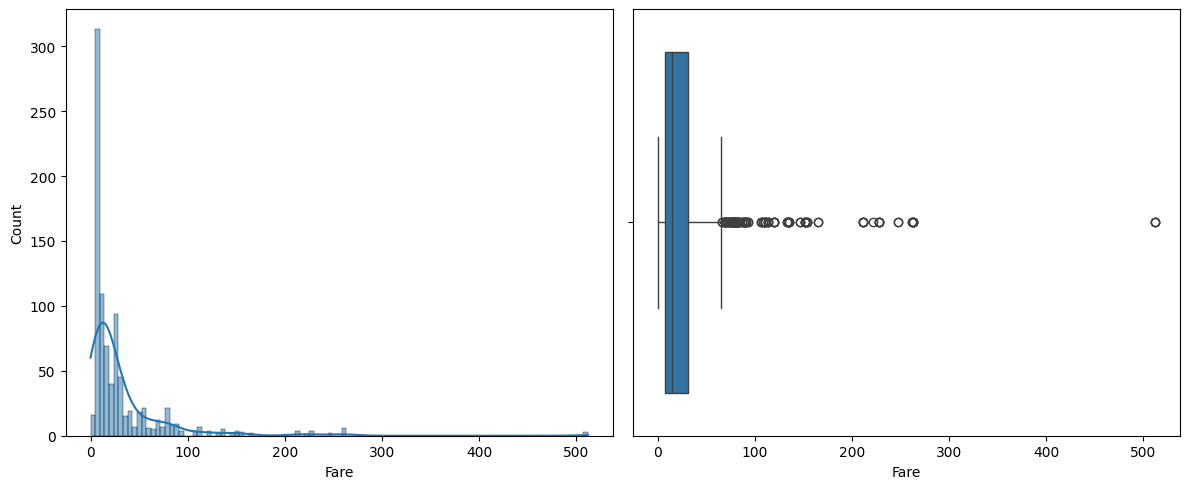

In [22]:
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df['Fare'], kde=True)

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df['Fare'])

plt.tight_layout()
plt.show()

**Observation**:

- Fare feature is highly right skwed and data is mostly concentrated between 0 to 50 and there are so many outliers on the right side

**Decision:**

- We have to use Power transformer yeo-johnson to make data normally distributed

# Outlier Analysis

Observations:

- Fare contains extreme values.
- Age contains mild outliers.
- Fare may benefit from logarithmic transformation.
- Extreme Fare values may require capping or transformation.

In [23]:
for i in df.columns:
  if i not in ['Age','Fare']:
    print(f"sns.countplot(data=df,x='{i}')")

sns.countplot(data=df,x='PassengerId')
sns.countplot(data=df,x='Survived')
sns.countplot(data=df,x='Pclass')
sns.countplot(data=df,x='Name')
sns.countplot(data=df,x='Sex')
sns.countplot(data=df,x='SibSp')
sns.countplot(data=df,x='Parch')
sns.countplot(data=df,x='Ticket')
sns.countplot(data=df,x='Cabin')
sns.countplot(data=df,x='Embarked')


<Axes: xlabel='Embarked', ylabel='count'>

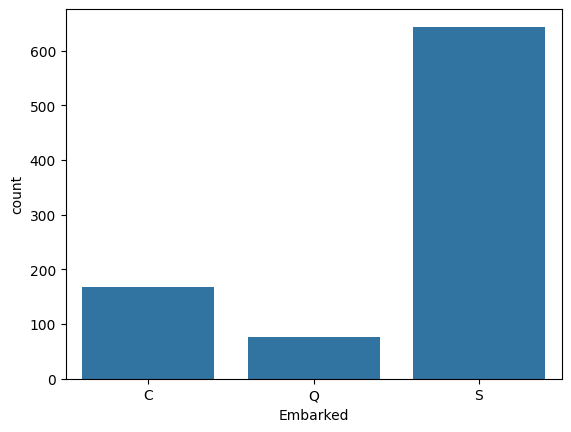

In [24]:
sns.countplot(data=df,x='Embarked')

In [25]:
df['Embarked'].value_counts(normalize=True)

,proportion
Embarked,
S,0.724409
C,0.188976
Q,0.086614


**Observation:**

- More than 70% of the people Embarked at Southampton and class are highly imbalance

**Decision:**

- This is an categorical feature so we have to encode befor modeling. Embarked may affect survival patterns.

<Axes: xlabel='Pclass', ylabel='count'>

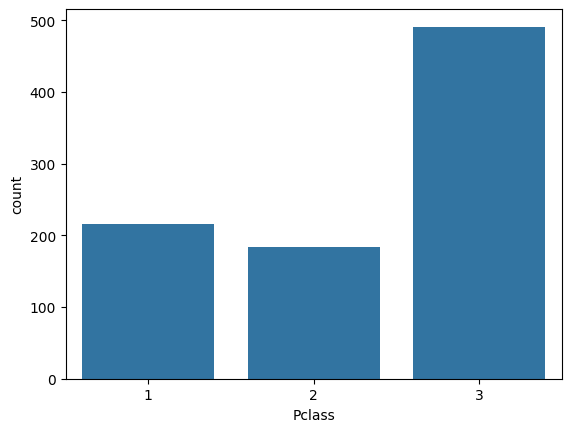

In [26]:
sns.countplot(data=df,x='Pclass')

In [27]:
df['Pclass'].value_counts(normalize=True)

,proportion
Pclass,
3,0.551066
1,0.242424
2,0.206510


**Observation:**

- Most passengers belong to Pclass 3 and fewer belong to Pclass 2



<Axes: xlabel='Sex', ylabel='count'>

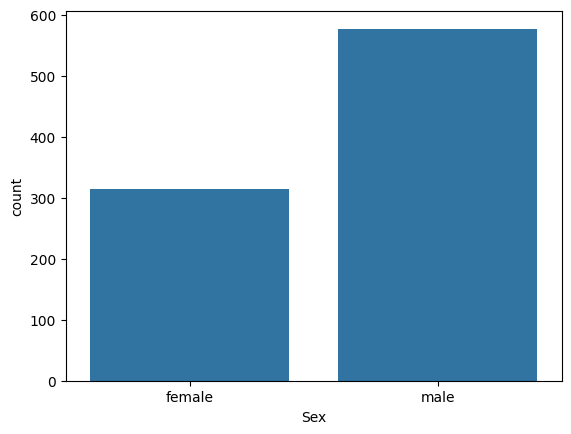

In [28]:
sns.countplot(data=df,x='Sex')

In [29]:
df['Sex'].value_counts(normalize=True)

,proportion
Sex,
male,0.647587
female,0.352413


**Observation:**

- Sex feature is imbalance and most of the data belongs to male class

**Decision:**

- This feature is categorical so we have to encode it before modeling

<Axes: xlabel='SibSp', ylabel='count'>

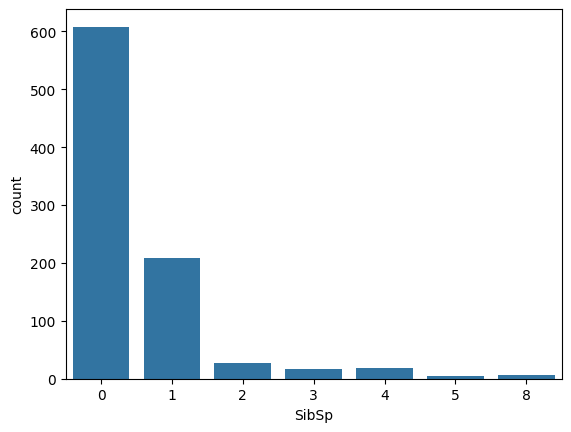

In [30]:
sns.countplot(data=df,x='SibSp')

In [31]:
df['SibSp'].value_counts(normalize=True)

,proportion
SibSp,
0,0.682379
1,0.234568
2,0.031425
4,0.020202
3,0.017957
8,0.007856
5,0.005612


**Obesrvation:**

- This feature show that most of the passengers are traveling alone or only one sibling/spouse

<Axes: xlabel='Parch', ylabel='count'>

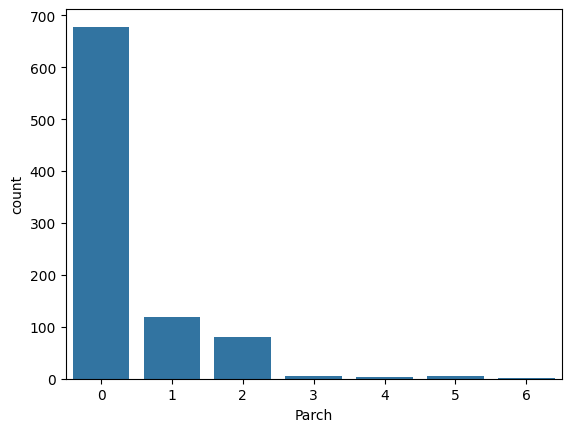

In [32]:
sns.countplot(data=df,x='Parch')

In [33]:
df['Parch'].value_counts(normalize=True)

,proportion
Parch,
0,0.760943
1,0.132435
2,0.089787
5,0.005612
3,0.005612
4,0.004489
6,0.001122


**Observation:**

- This feature also show that most of the passengers are traveling alone or with one/two parent childrens.

**Decision:**

- May be we can combine sibsp and parch and creat new feature

# **Bivariate Analysis**

<Axes: xlabel='Pclass', ylabel='count'>

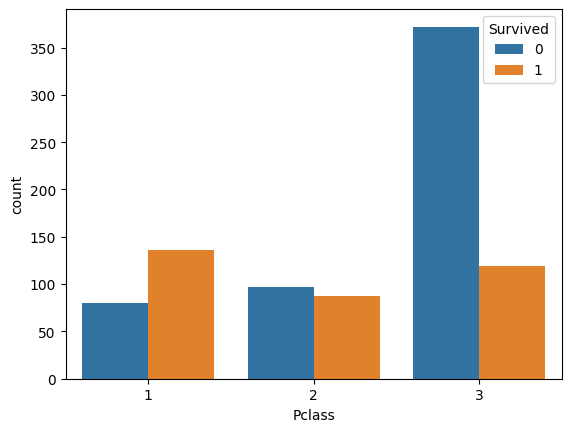

In [34]:

sns.countplot(data=df,x='Pclass',hue='Survived')

In [35]:
df.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

**Observation:**

- Pclass 1 has high survivel rate than other two classes and Pclass 2 have neer about 45 - 50% survivel rate
- Pclass 3 have more death rate. This could be because of fear, sex or age

<Axes: xlabel='Sex', ylabel='count'>

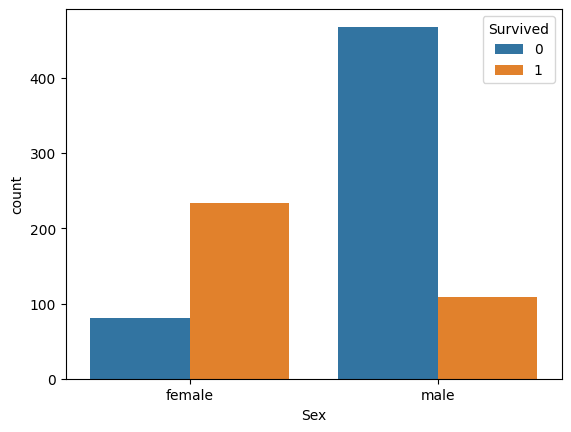

In [36]:
sns.countplot(data=df,x='Sex',hue='Survived')

In [37]:
df.groupby('Sex')['Survived'].mean()

/tmp/ipykernel_1398/2851150635.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Sex')['Survived'].mean()


,Survived
Sex,
female,0.742038
male,0.188908


**Observation:**

- Female survivel rate is high than male.
- It could be because they tried to save female and childrens

<Axes: xlabel='SibSp', ylabel='count'>

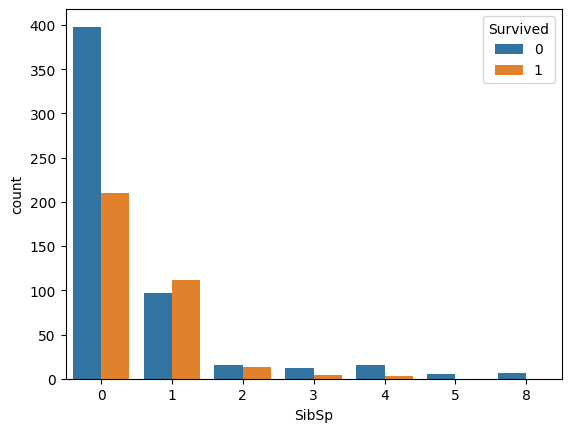

In [38]:
sns.countplot(data=df,x='SibSp',hue='Survived')

In [39]:
df.groupby('SibSp')['Survived'].mean()

,Survived
SibSp,
0,0.345395
1,0.535885
2,0.464286
3,0.250000
4,0.166667
5,0.000000
8,0.000000


**Observation:**

- The passenger who are traveling with 1 or 2 Sibling or Spouse they have more survivel rate.
- The big familys and alone travelers has less survivel rate

<Axes: xlabel='Parch', ylabel='count'>

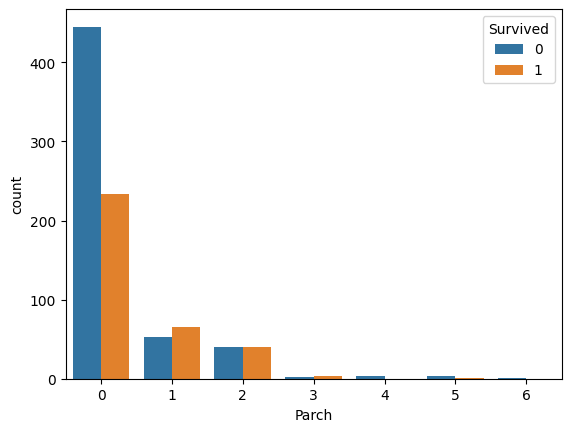

In [40]:
sns.countplot(data=df,x='Parch',hue='Survived')

In [41]:
df.groupby('Parch')['Survived'].mean()

,Survived
Parch,
0,0.343658
1,0.550847
2,0.500000
3,0.600000
4,0.000000
5,0.200000
6,0.000000


**Observation:**

- The passenger who are traveling with 1, 2 and 3 parent childrens they have more survivel rate.
- The big familys and alone travelers has less survivel rate

<Axes: xlabel='Embarked', ylabel='count'>

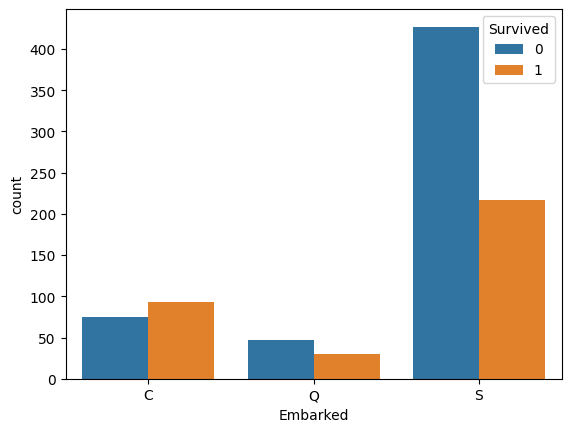

In [42]:
sns.countplot(data=df,x='Embarked',hue='Survived')

In [43]:
df.groupby('Embarked')['Survived'].mean()

/tmp/ipykernel_1398/1903666801.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Embarked')['Survived'].mean()


,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


**Observation:**

- Most of the passengers embarked from Southampton (s) and it has less survivel rate.
- Passengers embarked at Cherbourg (c) has more survivel rate than other two classes
- This could be because of fare or Pclass

<Axes: xlabel='Survived', ylabel='Age'>

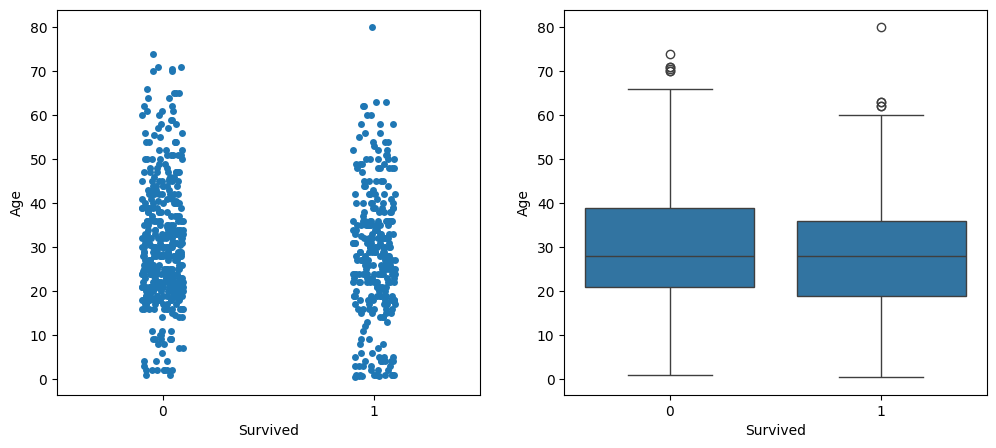

In [44]:
plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
sns.stripplot(data=df, x='Survived', y='Age')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Survived', y='Age')

**Observation:**

- The median age of survived and non-survived passengers is almost similar.
- Most passengers in both groups fall roughly between 20–40 years of age.
- Both categories contain some age outliers, especially elderly passengers around 70–80 years.
- The survived group appears to have slightly more younger passengers compared to the non-survived group.

**Decision:**

- Missing values in Age should be imputed before modeling.

<Axes: xlabel='Survived', ylabel='Fare'>

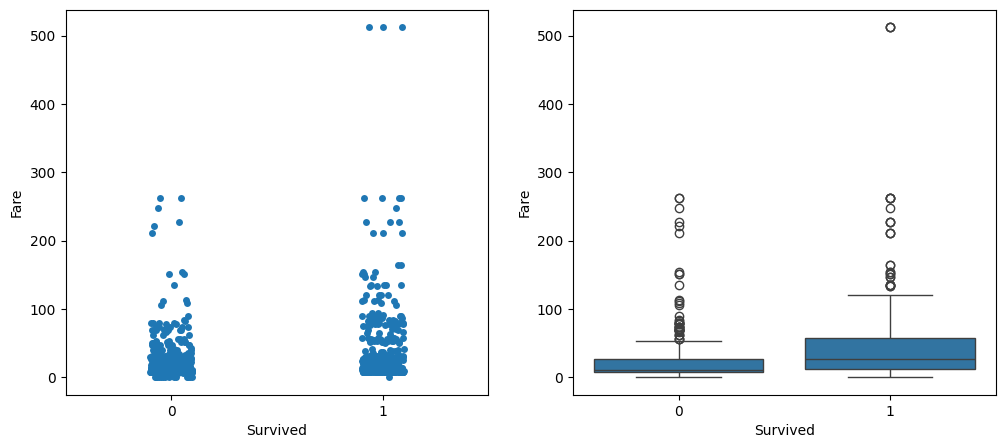

In [45]:
plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
sns.stripplot(data=df, x='Survived', y='Fare')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Survived', y='Fare')

**Observation:**

- The Fare feature is highly right-skewed.
- Most passengers paid lower fares, while a small number paid extremely high fares.
- Significant outliers are present in both survived and non-survived groups.
- Extremely high fares above 500 are present and may influence statistical measures like mean.

**Decision:**

- Consider applying log transformation to reduce skewness.

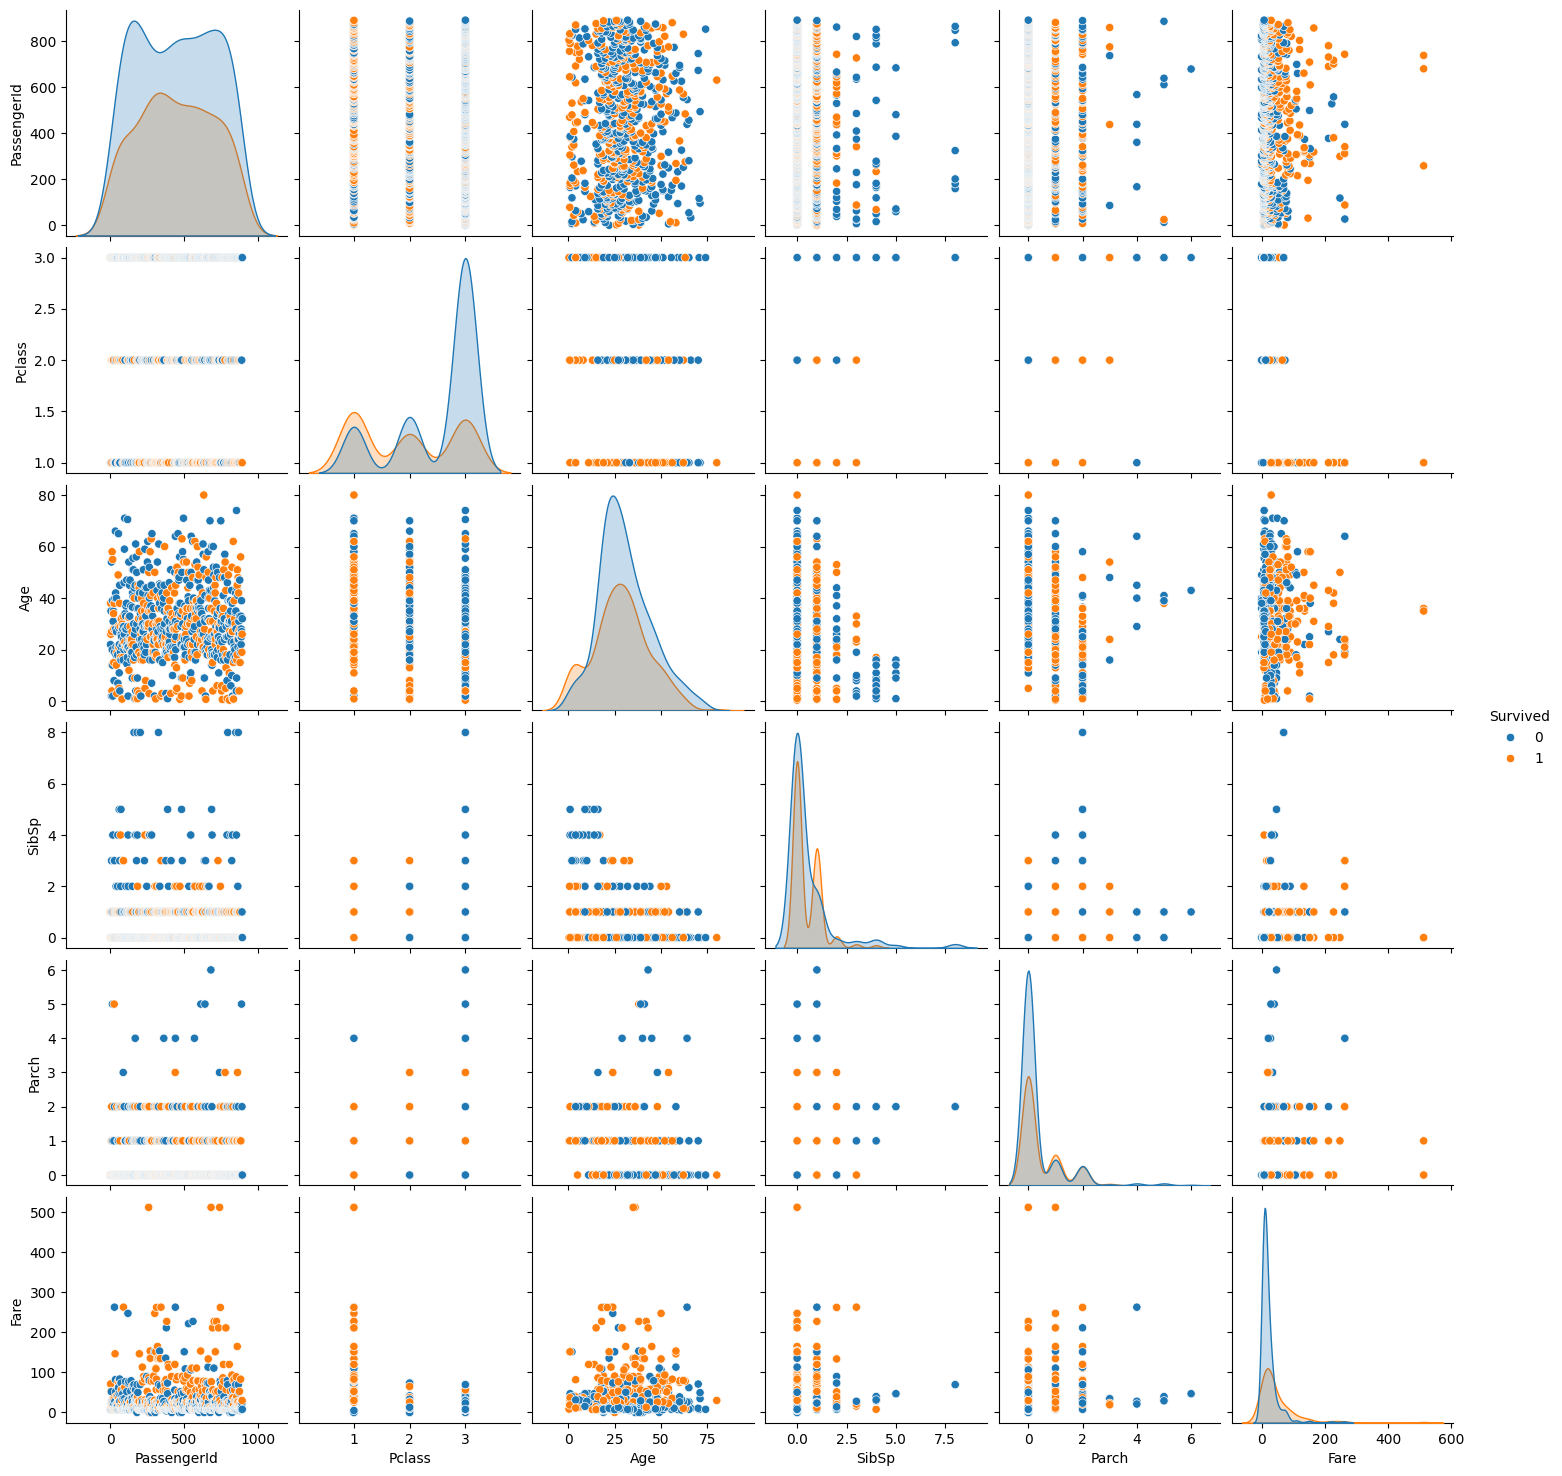

In [46]:
sns.pairplot(data = df,hue = 'Survived')

**Observation:**

- Most passengers belong to Pclass 3 with lower fares.
- Higher fare passengers are mostly from Pclass 1.
- Fare distribution is highly right-skewed with some extreme outliers.
- Most passengers traveled alone or with very small families (SibSp and Parch near 0).
- Survival appears higher among passengers with higher fares and lower Pclass values.
- Age distribution is concentrated mostly between 20–40 years.

**Decision:**

- Fare may need transformation because of skewness and outliers.
- Pclass, Fare, and family-related features may strongly influence survival.
- SibSp and Parch can be combined into a new family-size feature during feature engineering.


<Axes: >

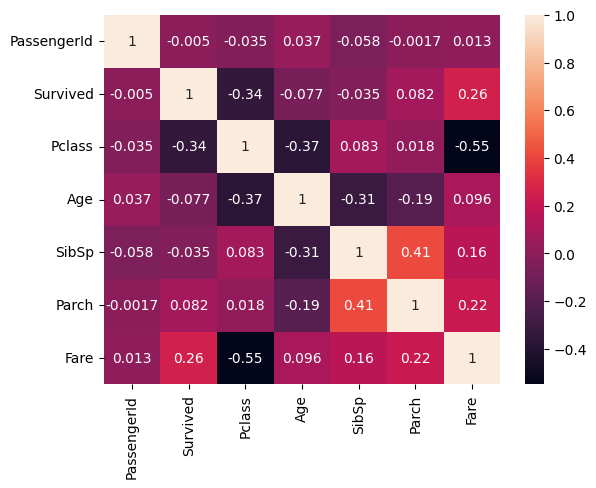

In [47]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

**Observation:**

- Pclass has a moderate negative correlation with Fare (-0.55), meaning higher-class passengers generally paid higher fares.
- Survived has a negative correlation with Pclass (-0.34), indicating lower-class passengers had lower survival rates.
- Fare shows a positive correlation with Survived (0.26), suggesting higher fare passengers survived more often.
- SibSp and Parch have moderate positive correlation (0.41), meaning family-related features are connected.
- Age has very weak correlation with Survived (-0.077).

**Decision:**

- Pclass and Fare appear to be important features for survival prediction.
- SibSp and Parch can potentially be combined into a family-size feature.
- Age alone may not strongly affect survival linearly.
- Correlation only captures linear relationships, so further analysis is still needed.

# Final Preprocessing Decisions

## Missing Values

- Age → Median Imputation
- Embarked → Mode Imputation
- Cabin → Drop

## Data Types

- Convert categorical string features into categorical data type

## Feature Engineering Ideas

- FamilySize = SibSp + Parch + 1
- IsAlone feature
- Title extraction from Name
- AgeGroup creation
- Fare transformation

## Encoding

- One-Hot Encode Embarked
- Encode Sex

## Outlier Treatment

- Apply log transformation to Fare
- Consider capping extreme Fare values

These decisions will be implemented in 02_feature_engineering.ipynb.